# Data Reduction (archival)

This tutorial will guide you through the process of finding, downloading, and reducing data from the Mikulski Archive for Space Telescopes (MAST) to create science-ready light curves. We'll primarily use the `lightkurve` Python package, a powerful tool for working with space telescope data like TESS, Kepler, and K2.

**Goal:** By the end of this tutorial, you'll be able to search for space telescope data, download it, perform basic reduction steps (like cleaning and normalization), and generate a light curve ready for analysis (e.g., searching for exoplanet transits or stellar variability).

**Environment:** This notebook is designed to work well in online Python IDEs like Google Colab or MS Visual Studio Code with a Python kernel.

## Introduction to MAST and Lightkurve

### What is MAST?
The **Mikulski Archive for Space Telescopes (MAST)** is NASA's primary archive for optical and ultraviolet astronomical data, with a strong focus on exoplanet-finding missions. It hosts data from missions like:
* **TESS (Transiting Exoplanet Survey Satellite):** Currently surveying most of the sky for nearby transiting exoplanets.
* **Kepler/K2:** Famous for discovering thousands of exoplanets using the transit method.
* Hubble Space Telescope (HST), GALEX, and others.

You can explore MAST visually via its portal: [https://mast.stsci.edu](https://mast.stsci.edu)

### What is Lightkurve?
**Lightkurve** is an open-source Python package designed to simplify the analysis of time-series astronomical data, especially from NASA's TESS, Kepler, and K2 missions. It provides tools for searching, downloading, processing, and plotting light curves and target pixel files (TPFs).

Official documentation: [https://docs.lightkurve.org](https://docs.lightkurve.org)

## Setting up Your Python Environment

To use `lightkurve`, you need Python and several astronomy/scientific packages, including `astropy`, `numpy`, and `matplotlib`. If you are using Google Colab, install `lightkurve` inside a notebook cell with:

```text
%pip install lightkurve
```

If you are working from a terminal or a local Anaconda prompt, use:

```bash
pip install lightkurve
```

```{admonition} Recommended local environment
:class: warning

If `import lightkurve` fails with an `autograd`, `oktopus`, or `numpy.linalg` error, you are probably using a package combination that is incompatible with NumPy 2.x. A clean conda environment with NumPy pinned below 2 is usually the easiest fix:

```bash
conda create -n lightkurve-env -c conda-forge python=3.11 "numpy<2" lightkurve astropy astroquery matplotlib scipy pandas jupyterlab ipykernel
conda activate lightkurve-env
python -m ipykernel install --user --name lightkurve-env --display-name "Python (lightkurve-env)"
```
```

Now, let's import `lightkurve` and other useful packages.

In [42]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

print(f"Lightkurve version: {lk.__version__}")
print(f"NumPy version: {np.__version__}")

Lightkurve version: 2.5.1
NumPy version: 2.4.4


## Searching for Data on MAST

`lightkurve` allows you to search for data programmatically. You can search by target name, mission-specific ID, or coordinates.

For the first tutorial example, we will use **WASP-18**, a bright star with a short-period transiting planet. This is a better first target than a long-period planet because one TESS sector contains many repeated transits. A short-period target makes the phase-folded light curve much easier to see when we intentionally limit the download to one sector/quarter.

```{admonition} Why not start with TOI 700 d?
:class: note

TOI 700 d is scientifically interesting, but it is not a good first-sector-only tutorial target. Its orbital period is long enough that one TESS sector may contain too few useful transits for a clear folded light curve. Start with a short-period planet first, then move to longer-period targets once the workflow is familiar.
```

In [43]:
target_star = "WASP-18"
mission = "TESS"
author = "SPOC"

# Other possible examples after you understand the workflow:
# target_star = "TOI 700"       # longer-period multi-planet system; usually needs more sectors
# target_star = "KIC 8462852"   # Kepler/Boyajian's Star example
# target_star = "TIC 150428135" # TIC identifier for TOI 700

search_result = lk.search_lightcurve(target_star, mission=mission, author=author)
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,SPOC,120,100100827,0.0
1,TESS Sector 03,2018,SPOC,120,100100827,0.0
2,TESS Sector 29,2020,SPOC,20,100100827,0.0
3,TESS Sector 30,2020,SPOC,20,100100827,0.0
4,TESS Sector 29,2020,SPOC,120,100100827,0.0
5,TESS Sector 30,2020,SPOC,120,100100827,0.0
6,TESS Sector 69,2023,SPOC,20,100100827,0.0
7,TESS Sector 69,2023,SPOC,120,100100827,0.0
8,TESS Sector 96,2025,SPOC,20,100100827,0.0


The `search_result` object is a table listing available light curve products for the target. It includes information such as the mission, sector/quarter/campaign, author or pipeline, exposure time, and observation ID.

For this tutorial, we intentionally keep only the **first available sector**. This keeps the page faster to build and gives students a smaller dataset to understand before they work with multi-sector light curves.

In [44]:
search_tess = search_result

if len(search_tess) == 0:
    raise RuntimeError(f"No {mission} {author} light curves were found for {target_star}.")

print(f"Found {len(search_tess)} {mission} {author} light curve products for {target_star}.")
print("For this tutorial, we will use only the first available product:")
search_tess[:1]

Found 10 TESS SPOC light curve products for WASP-18.
For this tutorial, we will use only the first available product:


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,SPOC,120,100100827,0.0


You can also search for Target Pixel Files (TPFs), which contain the raw pixel data around your target. This is useful if you want to perform custom photometry.

In [45]:
search_tpf_result = lk.search_targetpixelfile(target_star, mission=mission, author=author)

if len(search_tpf_result) == 0:
    print(f"No {mission} {author} target pixel files were found for {target_star}.")
else:
    print(f"Found {len(search_tpf_result)} target pixel file products. We will use only the first one later.")

search_tpf_result[:1]

Found 10 target pixel file products. We will use only the first one later.


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 02,2018,SPOC,120,100100827,0.0


## Understanding Data Products and Downloading Data

MAST provides several types of data products:

* **Light Curve Files (LCFs):** These files contain pre-processed light curves. For TESS and Kepler, common flux types include:
  * `SAP_FLUX` (Simple Aperture Photometry): the summed flux inside a pipeline aperture. It can still contain instrumental systematics.
  * `PDCSAP_FLUX` (Pre-search Data Conditioning SAP Flux): SAP flux corrected for many instrumental systematics. This is usually the best starting point for a first transit or variability search.
* **Target Pixel Files (TPFs):** These files contain the time-series images centered on the target star. They are useful when you want to inspect contamination, apertures, or extract your own light curve.

For speed and clarity, we will download only the first available light curve product. In a real research project, you may later download many sectors or quarters and stitch them together.

In [46]:
def convert_masked_flux_to_nan(lc):
    """Convert masked flux-like columns to ordinary arrays with NaNs.

    Some TESS products can store flux columns as masked quantities. That can cause
    errors later when cleaning, normalizing, or stitching. This helper replaces
    masked values with NaN values, which Lightkurve can remove cleanly.
    """
    lc = lc.copy()

    for colname in ["flux", "flux_err", "sap_flux", "sap_flux_err", "pdcsap_flux", "pdcsap_flux_err"]:
        if colname in lc.colnames:
            quantity = lc[colname]
            unit = getattr(quantity, "unit", None)

            try:
                values = quantity.filled(np.nan).value
            except AttributeError:
                values = quantity.value

            values = np.asarray(values, dtype=float)

            if unit is not None:
                lc[colname] = values * unit
            else:
                lc[colname] = values

    return lc

# Download only the first available light curve product.
# The flux_column argument asks Lightkurve to use PDCSAP flux when available.
lc0 = search_tess[0].download(flux_column="pdcsap_flux", quality_bitmask="default")
lc0 = convert_masked_flux_to_nan(lc0)

# Keep a one-item collection so the rest of the notebook still uses collection-style logic.
lc_collection = lk.LightCurveCollection([lc0])
lc_collection

LightCurveCollection of 1 objects:
    0: <TessLightCurve LABEL="TIC 100100827" SECTOR=2 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>

`lc_collection` is a `LightCurveCollection` object. In this tutorial, it contains only one light curve because we intentionally downloaded only the first available sector. Keeping the collection structure makes it easier to extend this notebook later to multiple sectors or quarters.

       time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1354.1115072617192     47745.6875 ... -1.2000147e-01  7.8144908e-02
1354.1128961919705 47782.17578125 ... -1.0294508e-01  6.7404680e-02
1354.1142851224547 47737.03515625 ... -1.0323820e-01  6.3302755e-02
 1354.117062983188 47739.65234375 ... -1.0774896e-01  5.0843615e-02
1354.1184519134392   47759.828125 ... -9.3161479e-02  8.3432972e-02
1354.1198408439234  47727.6953125 ... -9.2094876e-02  6.8144821e-02
1354.1212297741743  47743.8203125 ... -9.1556683e-02  6.7030065e-02
1354.1226187044247  47756.1640625 ... -9.4503127e-02  5.9139974e-02
1354.1240076349084 47734.61328125 ... -9.1448054e-02  6.1672445e-02
               ...            ... ...            ...            ...
1381.5049589636317  47716.5546875 ...  1.2310899e-02  6.2099039e-03
1381.5063478540658        47688.5 ...  1.8280700

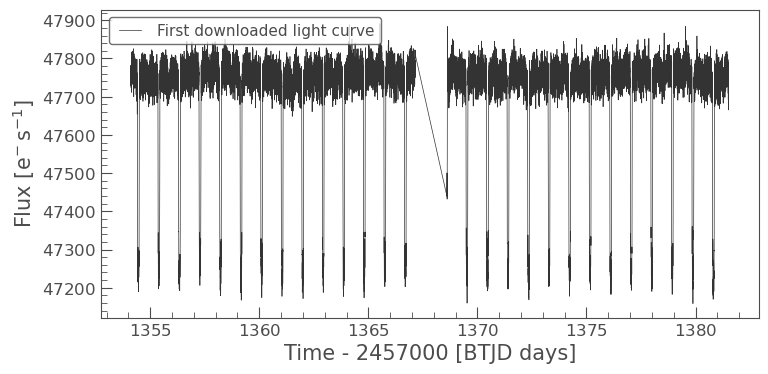

In [47]:
if len(lc_collection) > 0:
    lc0 = lc_collection[0]
    print(lc0)
    lc0.plot(label="First downloaded light curve")
else:
    print(f"No light curves found for {target_star}.")

The plot shows time on the x-axis and flux (usually `PDCSAP_FLUX` by default for `lk.LightCurve` objects from SPOC) on the y-axis. You can specify which flux column to plot:

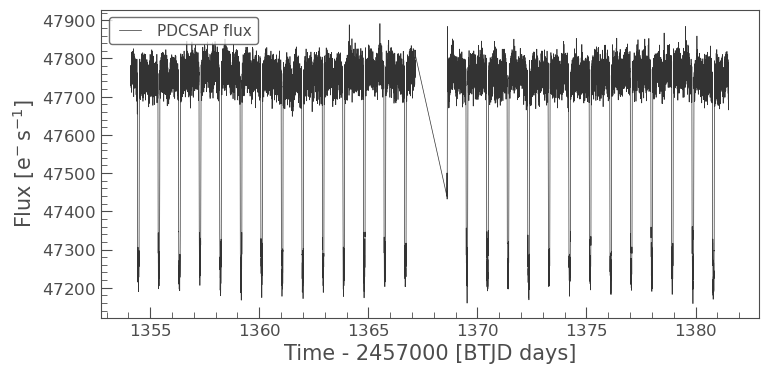

In [48]:
if len(lc_collection) > 0:
    lc0.plot(label="PDCSAP flux")
else:
    print("No light curve is available to plot.")

## Working with Light Curve Files (LCFs)

A `LightCurve` object has several useful attributes and methods.

* `lc.time`: time values, often in BJD or a mission-specific barycentric time system.
* `lc.flux`: flux values.
* `lc.flux_err`: uncertainty estimates on flux values.
* `lc.quality`: quality flags indicating potential issues with data points.

### Single-sector workflow

A common research workflow combines many sectors or quarters. For this tutorial, we do the opposite: we keep one sector so the notebook runs quickly and the plots are easier to interpret. That means we do **not** need to stitch multiple light curves here.

If you later use multiple sectors, clean and normalize each light curve first, then call `stitch(corrector_func=lambda lc: lc)` to avoid repeated normalization or masked-array errors.

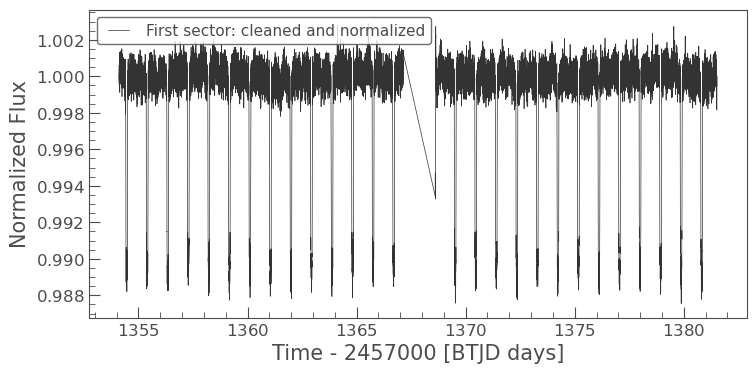

In [49]:
if len(lc_collection) > 0:
    # Clean and normalize the first sector only.
    stitched_lc = lc_collection[0].remove_nans().remove_outliers(sigma=5).normalize()
    stitched_lc.plot(label="First sector: cleaned and normalized")
else:
    stitched_lc = None
    print("No light curve is available to clean.")

### Data Cleaning with Quality Flags
Space telescope data often have quality flags indicating issues like cosmic ray hits, spacecraft manoeuvres, or bad pixels. `lightkurve` attempts to handle standard quality masking when loading data (especially for `PDCSAP_FLUX` which often has NaNs where corrections failed).

We've already used `remove_nans()` which is crucial for `PDCSAP_FLUX`. `remove_outliers()` was also applied above. These are good first steps in cleaning.

Points in the cleaned single-sector light curve: 18299


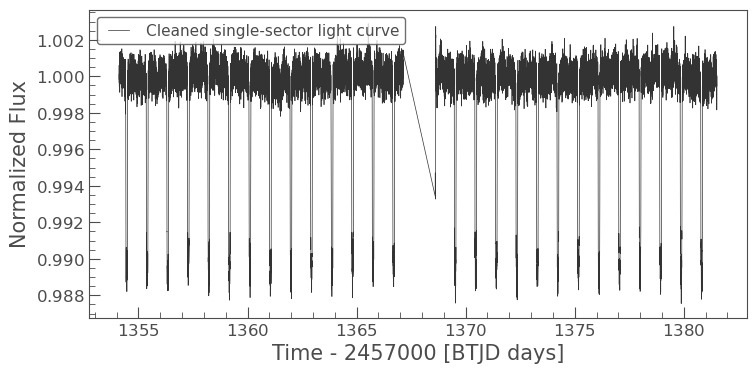

In [50]:
if 'stitched_lc' in locals() and stitched_lc is not None:
    cleaned_lc = stitched_lc
    print(f"Points in the cleaned single-sector light curve: {len(cleaned_lc.flux)}")
    cleaned_lc.plot(label="Cleaned single-sector light curve")
else:
    cleaned_lc = None
    print("Cleaned light curve is not available.")

### Normalization and Detrending

**Normalization** typically means dividing the flux by a representative baseline value so the out-of-transit flux is near 1.0. This makes transit depths easier to read as fractional changes in brightness.

**Detrending** removes slow variations from instrumental systematics or stellar variability. For a first pass, `lightkurve.flatten()` is a convenient option. It applies a Savitzky-Golay filter to estimate and remove low-frequency trends.

The `window_length` value is measured in cadences, not days. It should be long compared with the transit duration so the filter does not remove the transit itself.

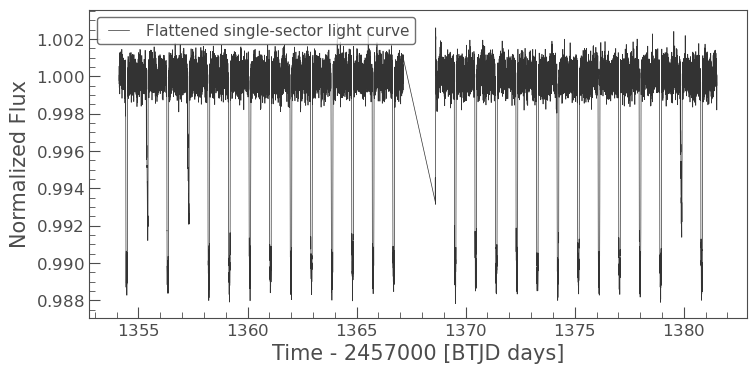

In [51]:
if 'cleaned_lc' in locals() and cleaned_lc is not None:
    try:
        # This is a simple first-pass detrending choice for a short-period hot Jupiter target.
        # For a science analysis, test several window lengths and verify that the transit depth is not distorted.
        flat_lc = cleaned_lc.flatten(window_length=401, polyorder=2)
        flat_lc.plot(label="Flattened single-sector light curve")
    except Exception as err:
        print(f"Flattening failed: {err}")
        print("Using the cleaned but unflattened light curve for the remaining examples.")
        flat_lc = cleaned_lc
        flat_lc.plot(label="Cleaned light curve")
else:
    flat_lc = None
    print("Cleaned light curve is not available for detrending.")

## Working with Target Pixel Files (TPFs) - Custom Photometry

If pre-processed light curves are not suitable, you can inspect the target pixel file and create your own light curve. This can matter if the target is blended with nearby stars, if the pipeline aperture is poor, or if you need to understand where the measured flux is coming from.

For this tutorial, we again use only the first available TPF so the notebook remains quick to run.

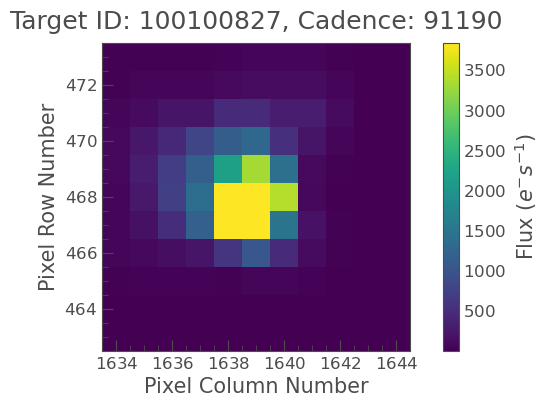

In [52]:
if len(search_tpf_result) > 0:
    print("Downloading the first available TPF only.")
    tpf = search_tpf_result[0].download(quality_bitmask="default")
    tpf.plot(frame=0)
else:
    tpf = None
    print(f"No TPFs found for {target_star} from {mission} {author}.")

The plot shows the pixel data. The red outline is the default pipeline aperture. You can define your own aperture interactively (in a Jupyter Notebook session by enabling `tpf.interact()`) or by creating a boolean mask programmatically.

### Creating a Custom Aperture Mask
Let's try to define a simple circular aperture or use a threshold mask. For this example, we'll use the pipeline's default aperture, which is often a good choice.

Pipeline aperture mask sum (pixels): 28


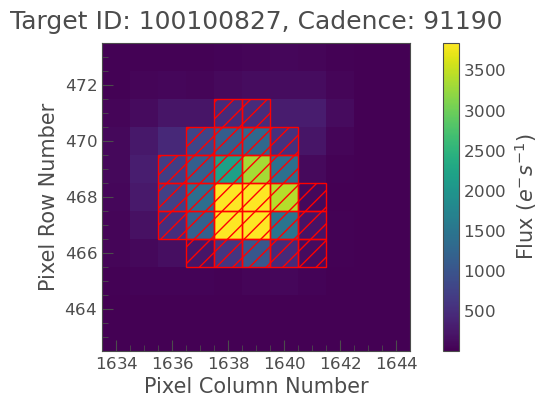

In [53]:
if 'tpf' in locals() and tpf is not None:
    # Using the pipeline-defined aperture mask
    pipeline_aperture = tpf.pipeline_mask
    tpf.plot(aperture_mask=pipeline_aperture, mask_color='red');
    print(f"Pipeline aperture mask sum (pixels): {pipeline_aperture.sum()}")

    # To create a custom threshold mask (alternative):
    # custom_aperture = tpf.create_threshold_mask(threshold=5) # threshold in sigma above median
    # tpf.plot(aperture_mask=custom_aperture, mask_color='blue');
    # print(f"Custom threshold aperture mask sum (pixels): {custom_aperture.sum()}")
else:
    print("TPF not available for aperture definition.")

### Performing Aperture Photometry
Once you have an aperture mask, you can extract the light curve using the `to_lightcurve()` method. This method will sum the flux within the aperture for each cadence.

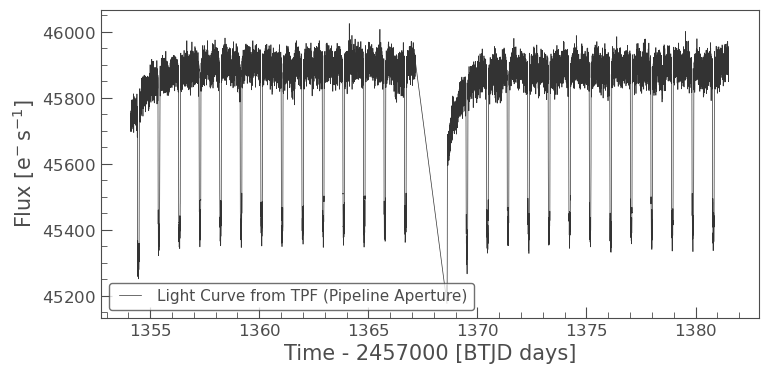

In [54]:
if 'tpf' in locals() and tpf is not None and 'pipeline_aperture' in locals() and pipeline_aperture.sum() > 0:
    custom_lc_from_tpf = tpf.to_lightcurve(aperture_mask=pipeline_aperture)
    custom_lc_from_tpf.plot(label="Light Curve from TPF (Pipeline Aperture)");
elif 'tpf' in locals() and hasattr(tpf, 'pipeline_mask') and tpf.pipeline_mask.sum() > 0: 
    print("Using pipeline mask as custom_mask was not effective or defined.")
    custom_lc_from_tpf = tpf.to_lightcurve(aperture_mask=tpf.pipeline_mask) # Fallback to pipeline mask
    custom_lc_from_tpf.plot(label="Pipeline Aperture Light Curve (from TPF)");
else:
    print("TPF or suitable aperture mask not available for custom photometry.")

This custom light curve is essentially a SAP (Simple Aperture Photometry) light curve. It will likely contain systematics from the instrument and spacecraft. You would then need to perform systematic correction (e.g., using `Regressors` in `lightkurve`, or methods like CBV, PLD if you delve deeper). For simplicity, we'll skip advanced custom systematic correction here and revert to using the PDCSAP flux from earlier (`flat_lc`) for the transit search example, as it has already undergone some systematic correction.

## Example: Finding and Folding a Transit

Now we will use the flattened light curve to find a repeating transit signal. Because the target is a short-period transiting planet system, one TESS sector should contain many transits. This makes it a better first tutorial example than a long-period planet.

Instead of hard-coding the period, we will use a **Box Least Squares** periodogram. BLS is designed to find box-shaped dips in a light curve, which makes it useful for transiting exoplanets.

The strongest BLS period is 0.94139 d.
The estimated transit midpoint is 1354.45951 btjd.
The estimated transit duration is 0.07600 d.


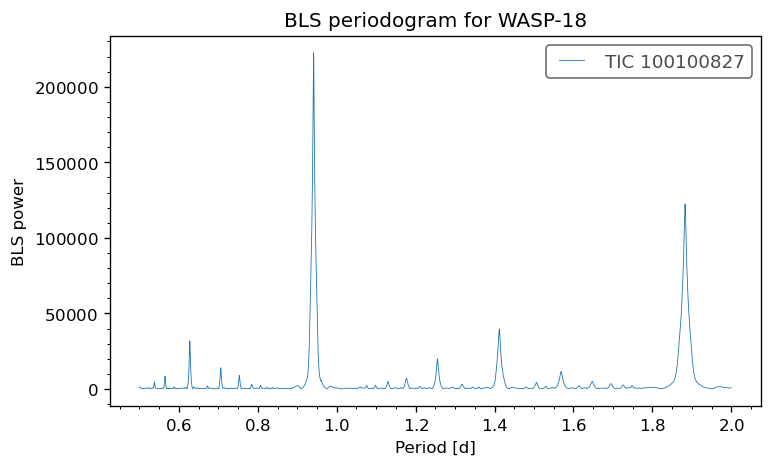

In [58]:
if 'flat_lc' in locals() and flat_lc is not None and len(flat_lc.remove_nans()) > 0:
    search_lc = flat_lc.remove_nans()

    # Search for short-period transits. WASP-18 b is a short-period planet, so this range is intentionally narrow.
    period_grid = np.linspace(0.5, 2.0, 5000)
    duration_grid = np.linspace(0.02, 0.20, 20)

    bls = search_lc.to_periodogram(method="bls", period=period_grid, duration=duration_grid)

    best_period = bls.period_at_max_power
    best_t0 = bls.transit_time_at_max_power
    best_duration = bls.duration_at_max_power

    best_period_days = best_period.value
    best_t0_value = best_t0.value
    best_duration_days = best_duration.value

    print(f"The strongest BLS period is {best_period_days:.5f} d.")
    print(f"The estimated transit midpoint is {best_t0_value:.5f} {best_t0.format}.")
    print(f"The estimated transit duration is {best_duration_days:.5f} d.")

    fig, ax = plt.subplots(figsize=(7, 4), dpi=120)

    bls.plot(ax=ax)

    ax.set_xlabel("Period [d]")
    ax.set_ylabel("BLS power")
    ax.set_title(f"BLS periodogram for {safe_target_name}")

    plt.show()
else:
    folded_lc = None
    print("Flattened light curve is not available or is empty for BLS and folding.")

The folded plot should show a repeated transit dip near phase zero. The unbinned points show the scatter in the data, while the binned curve shows the average transit shape more clearly.

```{admonition} First-sector limitation
:class: note

A single sector is good for a tutorial because it runs quickly and is easier to inspect. It is not always enough for a final research result. Longer-period planets, weak transits, or systems with strong stellar variability often require multiple sectors or quarters.
```

## Saving Your Reduced Light Curve

Once you have a processed light curve that you're happy with (e.g., `flat_lc` or `folded_lc`), you can save it to a file. Common formats include CSV or FITS.

**Note for Google Colab users:** Files saved this way will be stored in the temporary Colab environment. To save them permanently, you'll need to download them to your local machine or mount your Google Drive and save them there. You can find downloaded files in the file browser panel in Colab (usually on the left sidebar) and right-click to download.

In [56]:
if 'flat_lc' in locals() and flat_lc is not None and len(flat_lc.remove_nans()) > 0:
    safe_target_name = target_star.replace(" ", "_")

    output_filename_csv = f"{safe_target_name}_single_sector_flat_lightcurve.csv"
    flat_lc.to_csv(output_filename_csv, overwrite=True)
    print(f"Flattened light curve saved as: {output_filename_csv}")

    output_filename_fits = f"{safe_target_name}_single_sector_flat_lightcurve.fits"
    flat_lc.write(output_filename_fits, overwrite=True)
    print(f"Flattened light curve saved as: {output_filename_fits}")

    if 'folded_lc' in locals() and folded_lc is not None:
        output_filename_folded_csv = f"{safe_target_name}_single_sector_folded_lightcurve.csv"
        folded_lc.to_csv(output_filename_folded_csv, overwrite=True)
        print(f"Folded light curve saved as: {output_filename_folded_csv}")
else:
    print("No processed light curve is available to save.")

Flattened light curve saved as: WASP-18_single_sector_flat_lightcurve.csv
Flattened light curve saved as: WASP-18_single_sector_flat_lightcurve.fits


Folded light curve saved as: WASP-18_single_sector_folded_lightcurve.csv


## Conclusion and Further Steps

Congratulations! You've learned the basics of:
* Searching for data from space telescopes like TESS and Kepler using `lightkurve`.
* Limiting a tutorial workflow to the first sector/quarter so the analysis runs quickly and remains easy to inspect.
* Understanding the difference between Light Curve Files (LCFs) and Target Pixel Files (TPFs).
* Downloading and plotting light curves.
* Performing essential data reduction steps: cleaning, normalization, and detrending.
* Extracting a custom light curve from TPF data (basic aperture photometry).
* Phase-folding a light curve to look for periodic signals like exoplanet transits.
* Saving your processed light curve, with considerations for online IDEs.

**Further Steps for Your Research:**
* **Advanced Detrending:** Explore more sophisticated detrending techniques (e.g., Gaussian Processes, Cotrending Basis Vectors - CBVs, Pixel Level Decorrelation - PLD) if simple methods are insufficient.
* **Period Finding:** If the period of a signal is unknown, use period-finding algorithms (e.g., Box Least Squares for transits, Lomb-Scargle periodogram for stellar oscillations) available in `lightkurve` or `astropy.timeseries`.
* **Transit Modeling:** If you find a transit, you can model its shape to determine planetary parameters (radius, inclination, etc.) using packages like `exoplanet`, `batman`, or `PyTransit`.
* **Systematics Mitigation:** Deep dive into understanding and mitigating instrumental systematics specific to the mission you are working with.
* **Consult Documentation:** The [Lightkurve documentation](https://docs.lightkurve.org) is an excellent resource with many tutorials and API references.